In [1]:
import cv2
import numpy as np
from glob import glob

root_dir = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/data/raw-data/11-19-24/2. MoS2 on Sapphire"
sample_fps = glob(f"{root_dir}/*/*Current*.npy")
ex = sample_fps[0]

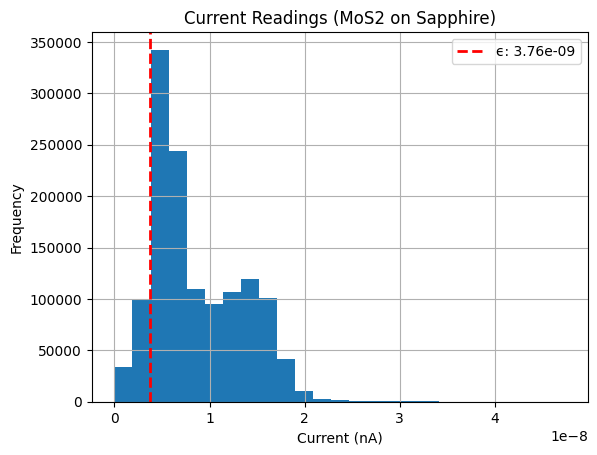

In [2]:
import matplotlib.pyplot as plt

all_current_readings = []

# for all files in sample_fps
# open data with shape 512, 512
# append all values to all_current_readings
for fp in sample_fps:
    data = np.load(fp)
    all_current_readings.append(data)

# reshape into 1d vector
all_current_readings = np.array(all_current_readings).reshape(-1)
# calculate the bottom 10th percentile
percentile_10 = np.percentile(all_current_readings, 10)

n, bins, patches = plt.hist(
    all_current_readings,
    bins=25,
)

plt.axvline(
    percentile_10,
    color='red',
    linestyle='dashed',
    linewidth=2,
    label=f'ϵ: {percentile_10:.2e}'
)

plt.xlabel('Current (nA)')
plt.ylabel('Frequency')
plt.title('Current Readings (MoS2 on Sapphire)')

plt.legend()
plt.grid()
plt.show()